In [ ]:
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from networkx.algorithms import community
from networkx.algorithms.community import greedy_modularity_communities

Jokowi_df = pd.read_csv(
    'Data Joko Widodo.csv',
    encoding='latin-1',
    engine='python',
)

Prabowo_df = pd.read_csv(
    'Data Prabowo Subianto.csv',
    encoding='latin-1',
    engine='python',
)

In [ ]:
# Menampilkan Info Dataset Jokowi
Jokowi_df.head()

Jokowi_df.info()
Jokowi_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   text           1000 non-null   object 
 1   favorited      1000 non-null   bool   
 2   favoriteCount  1000 non-null   int64  
 3   replyToSN      23 non-null     object 
 4   created        1000 non-null   object 
 5   truncated      1000 non-null   bool   
 6   replyToSID     22 non-null     float64
 7   id             1000 non-null   int64  
 8   replyToUID     23 non-null     float64
 9   statusSource   1000 non-null   object 
 10  screenName     1000 non-null   object 
 11  retweetCount   1000 non-null   int64  
 12  isRetweet      1000 non-null   bool   
 13  retweeted      1000 non-null   bool   
 14  longitude      1 non-null      float64
 15  latitude       1 non-null      float64
dtypes: bool(4), float64(4), int64(3), object(5)
memory usage: 97.8+ KB


,favoriteCount,replyToSID,id,replyToUID,retweetCount,longitude,latitude
count,1000.00000,2.200000e+01,1.000000e+03,2.300000e+01,1000.000000,1.000000,1.000000
mean,0.08700,1.128769e+18,1.133656e+18,2.498194e+17,14.270000,112.633195,-7.927563
std,1.02493,1.885719e+16,2.400893e+13,4.306624e+17,226.350404,NaN,NaN
min,0.00000,1.045983e+18,1.133582e+18,2.096343e+07,0.000000,112.633195,-7.927563
25%,0.00000,1.133416e+18,1.133645e+18,3.669872e+08,0.000000,112.633195,-7.927563
50%,0.00000,1.133537e+18,1.133655e+18,4.785466e+08,0.000000,112.633195,-7.927563
75%,0.00000,1.133673e+18,1.133665e+18,4.428894e+17,0.000000,112.633195,-7.927563
max,27.00000,1.133703e+18,1.133787e+18,1.022150e+18,5862.000000,112.633195,-7.927563


In [ ]:
# Menampilkan Info Dataset Prabowo

Prabowo_df.head()

Prabowo_df.info()
Prabowo_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   text           1000 non-null   object 
 1   favorited      1000 non-null   bool   
 2   favoriteCount  1000 non-null   int64  
 3   replyToSN      57 non-null     object 
 4   created        1000 non-null   object 
 5   truncated      1000 non-null   bool   
 6   replyToSID     57 non-null     float64
 7   id             1000 non-null   int64  
 8   replyToUID     58 non-null     float64
 9   statusSource   1000 non-null   object 
 10  screenName     1000 non-null   object 
 11  retweetCount   1000 non-null   int64  
 12  isRetweet      1000 non-null   bool   
 13  retweeted      1000 non-null   bool   
 14  longitude      0 non-null      float64
 15  latitude       0 non-null      float64
dtypes: bool(4), float64(4), int64(3), object(5)
memory usage: 97.8+ KB


,favoriteCount,replyToSID,id,replyToUID,retweetCount,longitude,latitude
count,1000.000000,5.700000e+01,1.000000e+03,5.800000e+01,1000.000000,0.0,0.0
mean,4.833000,1.133389e+18,1.133574e+18,2.680871e+17,319.671000,NaN,NaN
std,64.099953,4.499897e+14,1.352530e+14,4.424836e+17,460.160479,NaN,NaN
min,0.000000,1.131174e+18,1.133346e+18,3.562471e+06,0.000000,NaN,NaN
25%,0.000000,1.133331e+18,1.133422e+18,1.302959e+08,1.000000,NaN,NaN
50%,0.000000,1.133493e+18,1.133626e+18,3.163635e+08,56.000000,NaN,NaN
75%,0.000000,1.133632e+18,1.133686e+18,7.837175e+17,1026.000000,NaN,NaN
max,1846.000000,1.133759e+18,1.133762e+18,1.131429e+18,4318.000000,NaN,NaN


In [ ]:
import re

df = pd.concat([Jokowi_df, Prabowo_df])
df_retweet = df[df['isRetweet'] == True]

df_retweet['original_author'] = df_retweet['text'].str.extract(r'^RT @([A-Za-z0-9_]+):')

edges = df_retweet[['screenName', 'original_author']].dropna()
edges.columns = ['source', 'target']

/tmp/ipython-input-34-2601777057.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_retweet['original_author'] = df_retweet['text'].str.extract(r'^RT @([A-Za-z0-9_]+):')


In [ ]:
G = nx.DiGraph()
G.add_edges_from(edges.itertuples(index=False, name=None))

G_undirected = G.to_undirected()

In [ ]:
# Degree
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Centrality
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

# Clustering Coefficient

clustering_coefficient = nx.clustering(G_undirected)
graph_density = nx.density(G)

if nx.is_connected(G_undirected):
    avg_shortest_path_length = nx.average_shortest_path_length(G_undirected)
    diameter = nx.diameter(G_undirected)
else:
    largest_cc = max(nx.connected_components(G_undirected), key=len)
    subgraph = G_undirected.subgraph(largest_cc)
    avg_shortest_path_length = nx.average_shortest_path_length(subgraph)
    diameter = nx.diameter(subgraph)

print("Connected" if nx.is_connected(G_undirected) else "Not Connected")

Not Connected


In [ ]:
# Community Detection

communities = greedy_modularity_communities(G.to_undirected())

node_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i

komunitas_0 = [node for node in G.nodes() if node_community[node] == 0]
komunitas_1 = [node for node in G.nodes() if node_community[node] == 1]

subG = G.subgraph(komunitas_0)
subG = G.subgraph(komunitas_1)

do_ra_dong: 256x


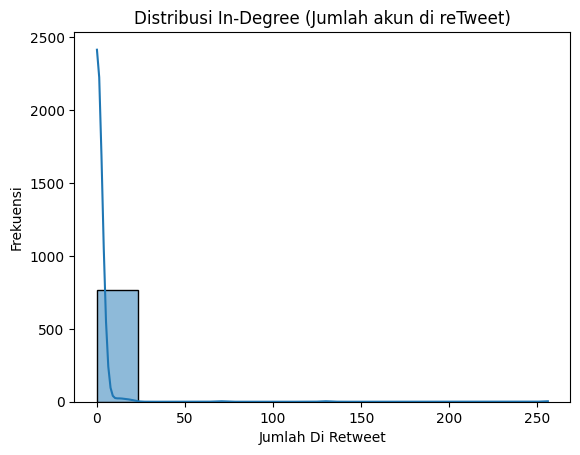

detikcom: 130x


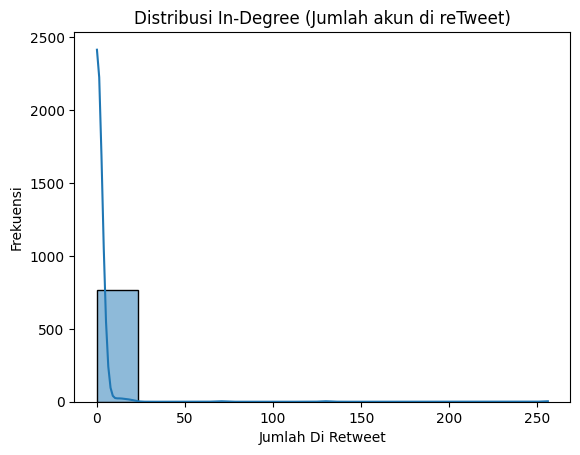

Ericssenw: 70x


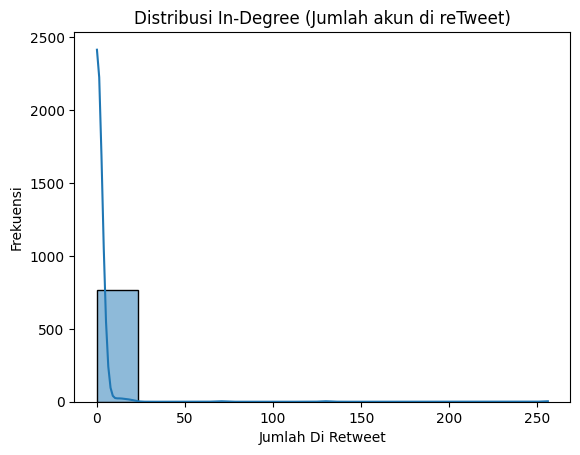

kumparan: 20x


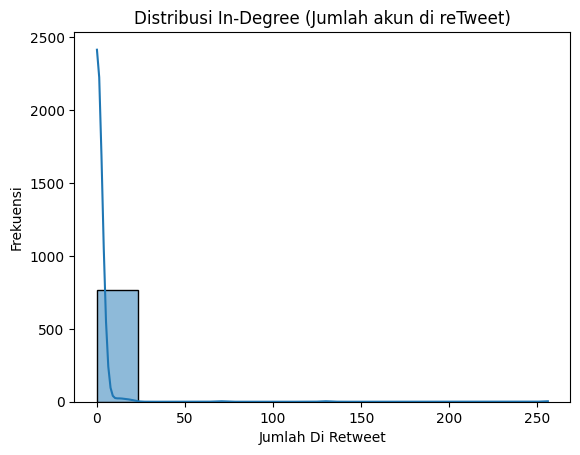

TirtoID: 19x


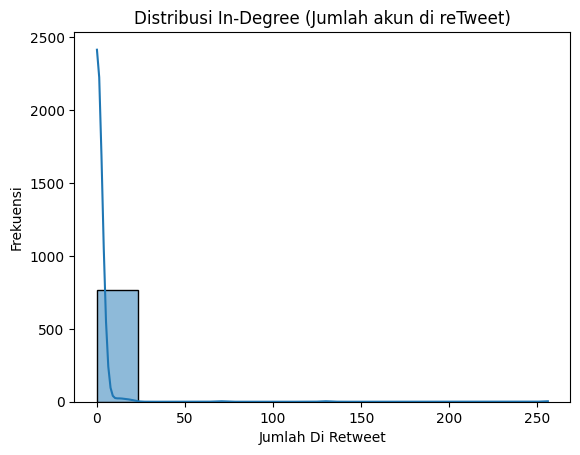

In [ ]:
# Distribusi In-Degree (jumlah akun di retweet)
top_retweeted = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:5]
for user, count in top_retweeted:
  print(f"{user}: {count}x")

  sns.histplot(list(in_degree.values()), kde=True)
  plt.title("Distribusi In-Degree (Jumlah akun di reTweet)")
  plt.xlabel("Jumlah Di Retweet")
  plt.ylabel("Frekuensi")
  plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

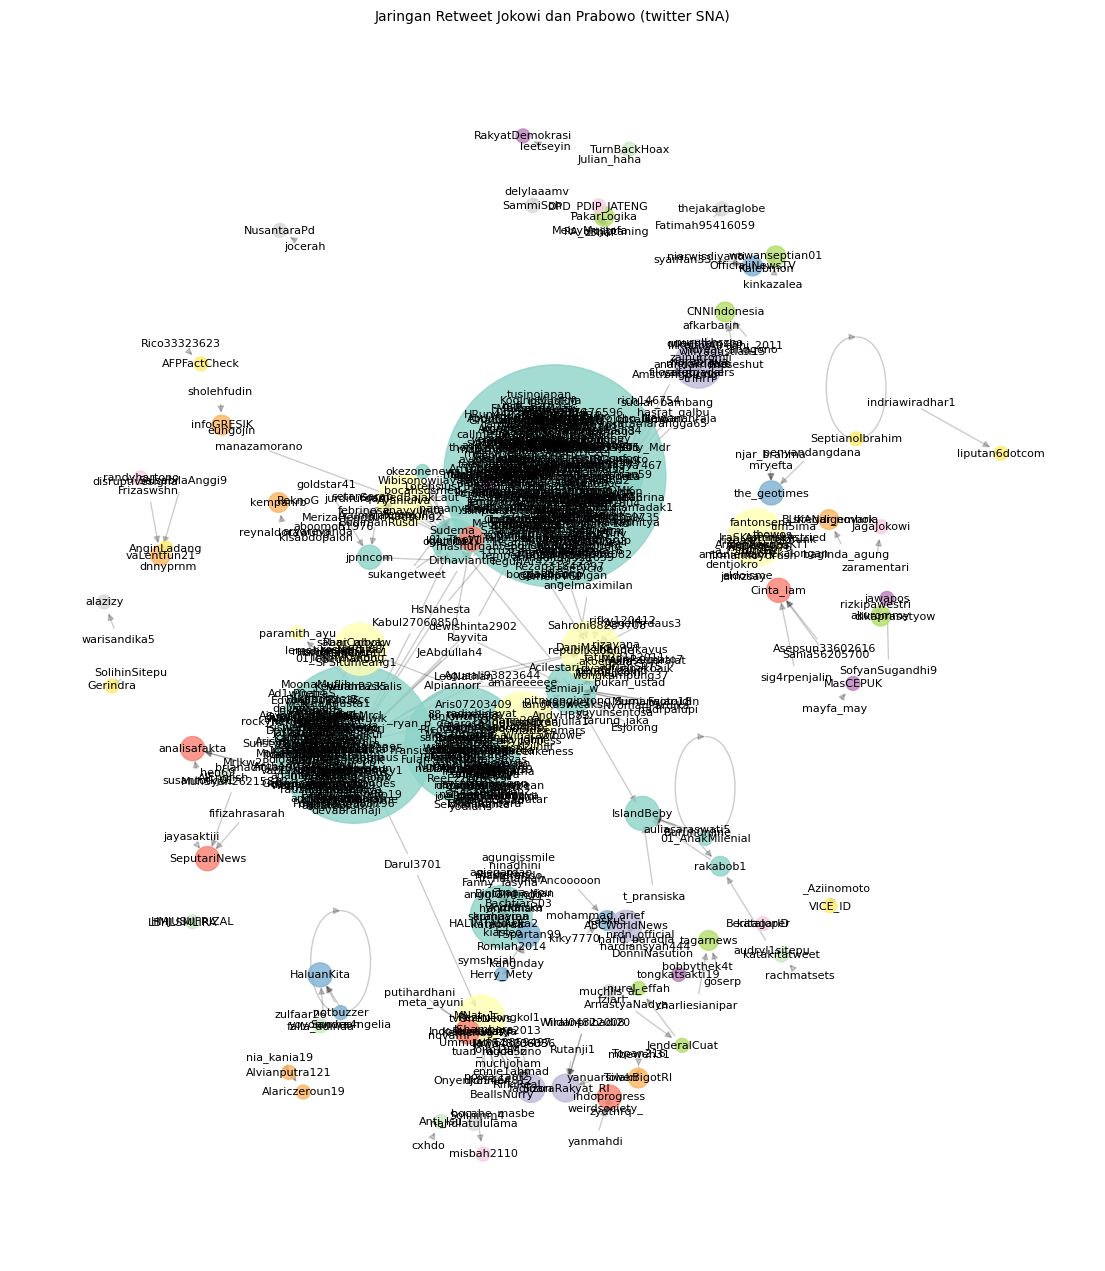

In [ ]:
# Visulasisasi Jaringan

plt.figure(figsize=(14, 16))
pos = nx.spring_layout(G, seed=12)
color_map = [node_community.get(node, 0) for node in G.nodes()]
node_size = [in_degree.get(node, 1) * 100 for node in G.nodes()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=color_map,
    cmap=plt.cm.Set3,
    node_size = node_size,
    alpha=0.8,
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2,
    arrows=True,
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8,
)

plt.title("Jaringan Retweet Jokowi dan Prabowo (twitter SNA)", fontsize=10)
plt.axis('off')
plt.show

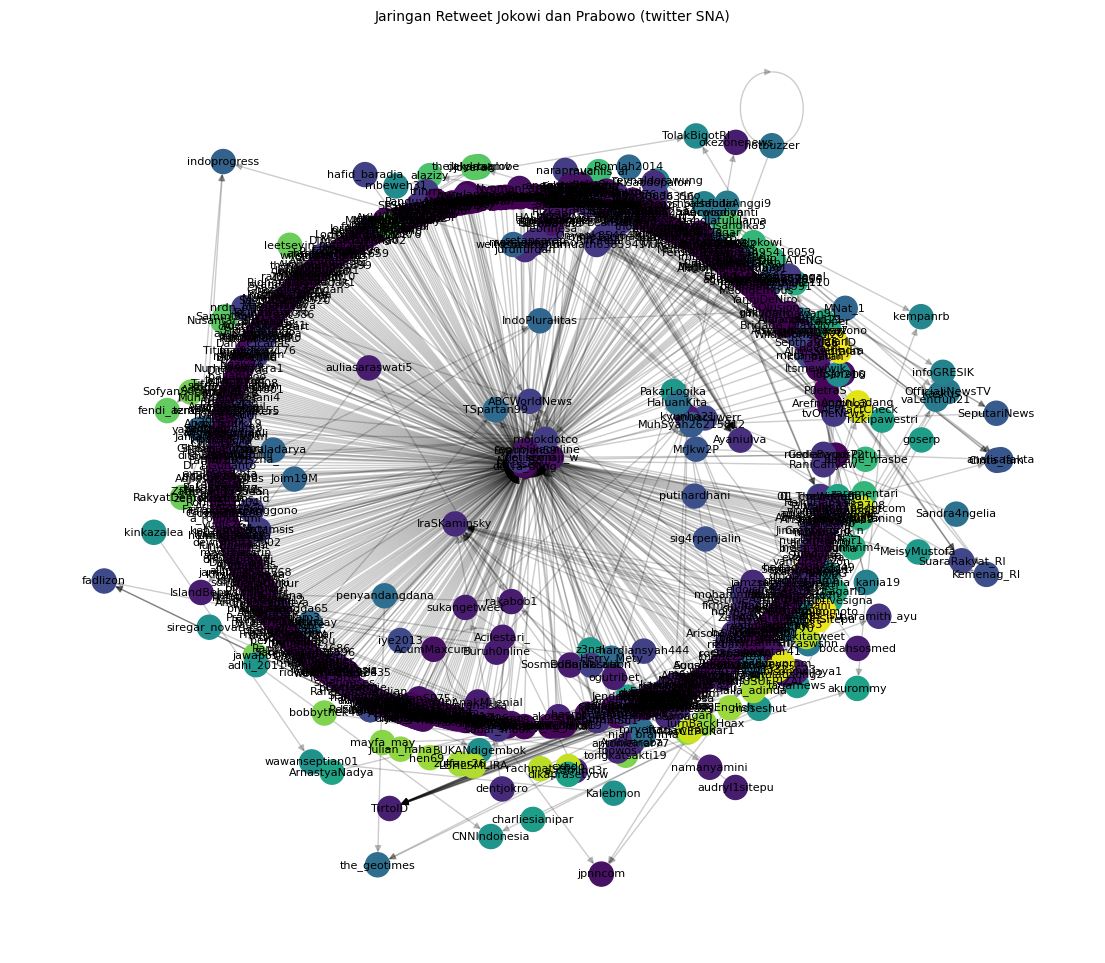

In [ ]:
layout = nx.kamada_kawai_layout(G)

plt.figure(figsize=(14, 12))

nx.draw_networkx_nodes(G, layout, node_color=[node_community.get(n,0) for n in G.nodes()])
nx.draw_networkx_edges(G, layout, alpha=0.2, arrows=True)
nx.draw_networkx_labels(G, layout, font_size=8)

plt.title("Jaringan Retweet Jokowi dan Prabowo (twitter SNA)", fontsize=10)
plt.axis('off')
plt.show()

In [ ]:
print("Jumlah node:", G.number_of_nodes())
print("Jumlah edge:", G.number_of_edges())
print("Jumlah komunitas:", len(communities))
print("Density jaringan:", graph_density)
print("Rata-rata shortest path:", avg_shortest_path_length)
print("Diameter jaringan:", diameter)

Jumlah node: 769
Jumlah edge: 732
Jumlah komunitas: 68
Density jaringan: 0.0012394343302990897
Rata-rata shortest path: 3.802512655833756
Diameter jaringan: 11


In [ ]:
# Weak-Tie Analysis

top_bridge_nodes = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
bridge_df = pd.DataFrame(top_bridge_nodes, columns=['Node', 'Betweenness Centrality'])

weak_ties = [(u, v) for u, v in G.edges() if node_community.get(u) != node_community.get(v)]
strong_ties = [(u, v) for u, v in G.edges() if node_community.get(u) == node_community.get(v)]

# Random Network Comparison

random_graph = nx.gnm_random_graph(n=G.number_of_nodes(), m=G.number_of_edges())
random_density = nx.density(random_graph)

if nx.is_connected(random_graph):
  random_avg_path = nx.average_shortest_path_length(random_graph)
  random_diameter = nx.diameter(random_graph)
else:
  largest_cc_random = max(nx.connected_components(random_graph), key=len)
  subgraph_random = random_graph.subgraph(largest_cc_random)
  random_avg_path = nx.average_shortest_path_length(subgraph_random)
  random_diameter = nx.diameter(subgraph_random)

In [ ]:
print("===== RINGKASAN JARINGAN =====")
print(f"Jumlah Node: {G.number_of_nodes()}")
print(f"Jumlah Edge: {G.number_of_edges()}")
print(f"Density (Asli): {graph_density:.5f}")
print(f"Density (Random): {random_density:.5f}")
print(f"Diameter (Asli): {diameter}")
print(f"Diameter (Random): {random_diameter}")
print(f"Rata-rata Path (Asli): {avg_shortest_path_length:.2f}")
print(f"Rata-rata Path (Random): {random_avg_path:.2f}")
print(f"Weak Ties (antar komunitas): {len(weak_ties)}")
print(f"Strong Ties (dalam komunitas): {len(strong_ties)}")

print("\n===== Top 5 Bridge Nodes (Weak Ties) =====")
print(bridge_df.head(5))

===== RINGKASAN JARINGAN =====
Jumlah Node: 769
Jumlah Edge: 732
Density (Asli): 0.00124
Density (Random): 0.00248
Diameter (Asli): 11
Diameter (Random): 21
Rata-rata Path (Asli): 3.80
Rata-rata Path (Random): 8.76
Weak Ties (antar komunitas): 26
Strong Ties (dalam komunitas): 706

===== Top 5 Bridge Nodes (Weak Ties) =====
              Node  Betweenness Centrality
0         kyunha21                0.000017
1     JenderalCuat                0.000002
2         rakabob1                0.000002
3  disruptivesigna                0.000000
4     randyhartono                0.000000
